In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.stats import norm
import math
import pandas as pd
import seaborn as sns
import os
import sys
import polars as pl

In [2]:
df = pd.read_parquet("/home/crimsondeepdarshak/Desktop/Deep_Darshak/References/TRAIS_former_paper_Work_/CEE-Replication/Notebook/region_1_interpolated.parquet")
df

,Time,MMSI,Longitude,Latitude,SOG,COG,IMO,Vessel type,Navstatus,is_interpolated
0,2025-01-01 00:01:44,103669999,-89.08701,30.364400,0.000000,313.100000,None,37,None,False
1,2025-01-01 00:11:44,103669999,-89.08719,30.364278,0.002151,313.034297,None,37,None,True
2,2025-01-01 00:21:44,103669999,-89.08737,30.364157,0.004301,312.968593,None,37,None,True
3,2025-01-01 00:31:44,103669999,-89.08755,30.364035,0.006452,312.902890,None,37,None,True
4,2025-01-01 00:41:44,103669999,-89.08773,30.363914,0.008602,312.837186,None,37,None,True
...,...,...,...,...,...,...,...,...,...,...
28274614,2025-01-30 16:32:35,998975541,-87.55923,30.284763,0.000000,148.000000,IMO6702284,37,0,True
28274615,2025-01-30 16:42:35,998975541,-87.55923,30.284762,0.000000,148.000000,IMO6702284,37,0,True
28274616,2025-01-30 16:52:35,998975541,-87.55923,30.284762,0.000000,148.000000,IMO6702284,37,0,True
28274617,2025-01-30 17:02:35,998975541,-87.55923,30.284761,0.000000,148.000000,IMO6702284,37,0,True


In [4]:
df.describe()

,Time,Longitude,Latitude,SOG,COG
count,28274619,2.827462e+07,2.827462e+07,2.827462e+07,2.827462e+07
mean,2025-01-16 10:45:15.694015,-8.839541e+01,2.861963e+01,2.420665e+00,1.838371e+02
min,2025-01-01 00:00:00,-9.873876e+01,1.744450e+01,0.000000e+00,0.000000e+00
25%,2025-01-09 01:45:39,-9.326122e+01,2.771224e+01,0.000000e+00,1.135409e+02
50%,2025-01-16 08:22:57,-8.986745e+01,2.922185e+01,1.000000e-01,1.891405e+02
75%,2025-01-23 20:08:41.500000,-8.255809e+01,2.991466e+01,3.362166e+00,2.568000e+02
max,2025-01-31 23:59:51,-8.020287e+01,3.110031e+01,9.080000e+01,3.599000e+02
std,NaN,5.388509e+00,1.731838e+00,4.318783e+00,8.959291e+01


In [5]:
df.columns

Index(['Time', 'MMSI', 'Longitude', 'Latitude', 'SOG', 'COG', 'IMO',
       'Vessel type', 'Navstatus', 'is_interpolated'],
      dtype='object')

# Embedding architecture

    Raw AIS (lat, lon, SOG, COG)
        ↓
    Discretization (bins)
            ↓
    Four-hot (sparse representation)
            ↓
    Embedding lookup
            ↓
    Concatenated embedding vector e_t
            ↓
    Midpoint reconstruction (for error analysis)
            ↓
    Visualization at each stage

## We will be building 6 operators
    1. AISConfig                 → hyperparameters
    2. AISDiscretizer            → x_t → bin indices
    3. AISFourHotEncoder         → bin indices → four-hot sparse tensor
    4. AISEmbeddingBuilder       → four-hot → e_t
    5. AISReconstructor          → bins → midpoint x̂_t
    6. AISVisualizer             → diagnostics + hyperparameter impact

In [6]:
import torch
import numpy as np

class AISConfig:
    def __init__(
        self,
        lat_range,
        lon_range,
        lat_res=0.01,
        lon_res=0.01,
        sog_res=1.0,
        cog_res=5.0,
        max_sog=40,
        embed_dim=64,
        device="cuda"
    ):
        self.lat_min, self.lat_max = lat_range
        self.lon_min, self.lon_max = lon_range

        self.lat_res = lat_res
        self.lon_res = lon_res
        self.sog_res = sog_res
        self.cog_res = cog_res
        self.max_sog = max_sog
        self.embed_dim = embed_dim

        self.device = torch.device(device if torch.cuda.is_available() else "cpu")

        # Bin counts
        self.N_lat = int((self.lat_max - self.lat_min) / lat_res)
        self.N_lon = int((self.lon_max - self.lon_min) / lon_res)
        self.N_sog = int(max_sog / sog_res)
        self.N_cog = int(360 / cog_res)

    def summary(self):
        print("===== AIS CONFIG =====")
        print("Lat bins:", self.N_lat)
        print("Lon bins:", self.N_lon)
        print("SOG bins:", self.N_sog)
        print("COG bins:", self.N_cog)
        print("Embedding dimension per attribute:", self.embed_dim)
        print("Total embedding dimension:", self.embed_dim * 4)

/home/crimsondeepdarshak/Desktop/Deep_Darshak/code_/env/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [7]:
class AISDiscretizer:
    def __init__(self, config):
        self.cfg = config

    def forward(self, tensor):

        lat, lon, sog, cog = tensor.T

        lat_bin = torch.floor(
            (lat - self.cfg.lat_min) / self.cfg.lat_res
        ).long()

        lon_bin = torch.floor(
            (lon - self.cfg.lon_min) / self.cfg.lon_res
        ).long()

        sog_bin = torch.floor(sog / self.cfg.sog_res).long()
        cog_bin = torch.floor(cog / self.cfg.cog_res).long()

        return lat_bin, lon_bin, sog_bin, cog_bin

In [8]:
class AISFourHotEncoder:
    def __init__(self, config):
        self.cfg = config

    def forward(self, lat_bin, lon_bin, sog_bin, cog_bin):

        N = len(lat_bin)

        lat_onehot = torch.zeros((N, self.cfg.N_lat), device=self.cfg.device)
        lon_onehot = torch.zeros((N, self.cfg.N_lon), device=self.cfg.device)
        sog_onehot = torch.zeros((N, self.cfg.N_sog), device=self.cfg.device)
        cog_onehot = torch.zeros((N, self.cfg.N_cog), device=self.cfg.device)

        lat_onehot[torch.arange(N), lat_bin] = 1
        lon_onehot[torch.arange(N), lon_bin] = 1
        sog_onehot[torch.arange(N), sog_bin] = 1
        cog_onehot[torch.arange(N), cog_bin] = 1

        four_hot = torch.cat(
            [lat_onehot, lon_onehot, sog_onehot, cog_onehot], dim=1
        )

        return four_hot

In [9]:
import torch.nn as nn

class AISEmbeddingBuilder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.cfg = config

        self.lat_embed = nn.Embedding(config.N_lat, config.embed_dim)
        self.lon_embed = nn.Embedding(config.N_lon, config.embed_dim)
        self.sog_embed = nn.Embedding(config.N_sog, config.embed_dim)
        self.cog_embed = nn.Embedding(config.N_cog, config.embed_dim)

    def forward(self, lat_bin, lon_bin, sog_bin, cog_bin):

        e_lat = self.lat_embed(lat_bin)
        e_lon = self.lon_embed(lon_bin)
        e_sog = self.sog_embed(sog_bin)
        e_cog = self.cog_embed(cog_bin)

        e = torch.cat([e_lat, e_lon, e_sog, e_cog], dim=-1)

        return e

In [10]:
class AISReconstructor:
    def __init__(self, config):
        self.cfg = config

    def reconstruct(self, lat_bin, lon_bin, sog_bin, cog_bin):

        lat = self.cfg.lat_min + (lat_bin + 0.5) * self.cfg.lat_res
        lon = self.cfg.lon_min + (lon_bin + 0.5) * self.cfg.lon_res
        sog = (sog_bin + 0.5) * self.cfg.sog_res
        cog = (cog_bin + 0.5) * self.cfg.cog_res

        return torch.stack([lat, lon, sog, cog], dim=1)

In [11]:
import matplotlib.pyplot as plt

class AISVisualizer:

    @staticmethod
    def spatial_grid_plot(lat_bin, lon_bin):
        plt.figure(figsize=(6,6))
        plt.scatter(lon_bin.cpu(), lat_bin.cpu(), s=1)
        plt.title("Spatial Grid Occupancy")
        plt.show()

    @staticmethod
    def bin_histogram(bin_tensor, title):
        plt.figure()
        plt.hist(bin_tensor.cpu().numpy(), bins=50)
        plt.title(title)
        plt.show()

    @staticmethod
    def reconstruction_error(original, reconstructed):

        error = torch.norm(original - reconstructed, dim=1)

        plt.figure()
        plt.hist(error.cpu().numpy(), bins=50)
        plt.title("Reconstruction Error Distribution")
        plt.show()

        print("Mean error:", error.mean().item())

===== AIS CONFIG =====
Lat bins: 1365
Lon bins: 1853
SOG bins: 40
COG bins: 72
Embedding dimension per attribute: 64
Total embedding dimension: 256


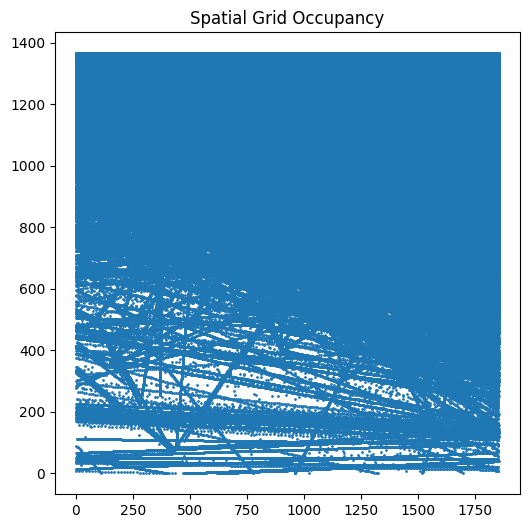

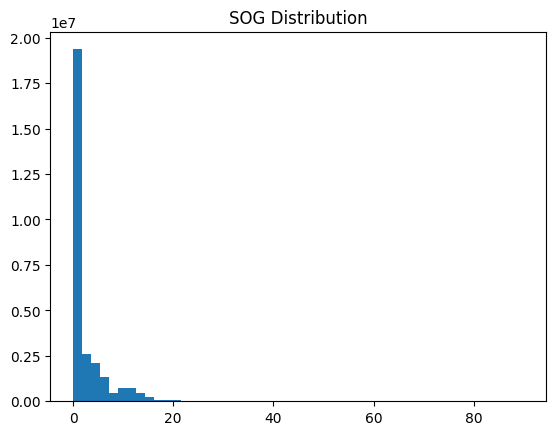

/pytorch/aten/src/ATen/native/cuda/IndexKernelUtils.cu:16: vectorized_gather_kernel: block: [888492,0,0], thread: [0,0,0] Assertion `ind >=0 && ind < ind_dim_size && "vectorized gather kernel index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernelUtils.cu:16: vectorized_gather_kernel: block: [888492,0,0], thread: [1,0,0] Assertion `ind >=0 && ind < ind_dim_size && "vectorized gather kernel index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernelUtils.cu:16: vectorized_gather_kernel: block: [888492,0,0], thread: [2,0,0] Assertion `ind >=0 && ind < ind_dim_size && "vectorized gather kernel index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernelUtils.cu:16: vectorized_gather_kernel: block: [888492,0,0], thread: [3,0,0] Assertion `ind >=0 && ind < ind_dim_size && "vectorized gather kernel index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernelUtils.cu:16: vectorized_gather_kernel: block: [888492,0,0], thread

OutOfMemoryError: CUDA out of memory. Tried to allocate 6.74 GiB. GPU 0 has a total capacity of 11.60 GiB of which 2.51 GiB is free. Including non-PyTorch memory, this process has 8.39 GiB memory in use. Of the allocated memory 8.01 GiB is allocated by PyTorch, and 218.48 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [12]:
# Example usage

config = AISConfig(
    lat_range=(df.Latitude.min(), df.Latitude.max()),
    lon_range=(df.Longitude.min(), df.Longitude.max()),
    lat_res=0.01,
    lon_res=0.01,
    sog_res=1.0,
    cog_res=5.0,
    embed_dim=64
)

config.summary()

tensor = torch.tensor(
    df[["Latitude", "Longitude", "SOG", "COG"]].values,
    dtype=torch.float32,
    device=config.device
)

discretizer = AISDiscretizer(config)
lat_bin, lon_bin, sog_bin, cog_bin = discretizer.forward(tensor)

visualizer = AISVisualizer()
visualizer.spatial_grid_plot(lat_bin, lon_bin)
visualizer.bin_histogram(sog_bin, "SOG Distribution")

embedding_builder = AISEmbeddingBuilder(config).to(config.device)
embeddings = embedding_builder(lat_bin, lon_bin, sog_bin, cog_bin)

reconstructor = AISReconstructor(config)
reconstructed = reconstructor.reconstruct(
    lat_bin, lon_bin, sog_bin, cog_bin
)

visualizer.reconstruction_error(tensor, reconstructed)

### Important Insight for Your Maritime Research

Smaller bins:

Better lane resolution

Higher memory

Higher sparsity

Larger bins:

Smoother lanes

Better generalization

Lower variance

This becomes a maritime bias-variance tradeoff.